# Neuronale Netze 7: Matrizenmultiplikation
## Von vielen Einzelrechnungen zu einer kurzen Rechnung

In Colab 05 haben wir ein kleines künstliches Neuron und ein kleines **2x2 Netz** noch Schritt für Schritt gerechnet.

Heute lernen wir eine Abkürzung:

> Viele Rechnungen mit Eingaben und Gewichten kann man als **Matrizenmultiplikation** schreiben.

Eine Matrix ist dabei nichts Geheimnisvolles.

> Eine **Matrix** ist einfach eine **Tabelle mit Zahlen**.

### Das Ziel heute
1. Du erkennst **Zeilen** und **Spalten** in einer Matrix.
2. Du verstehst die Regel **Zeile mal Spalte**.
3. Du siehst den Unterschied zwischen `*` und `@` in Python.
4. Du rechnest das kleine Netz aus Colab 05 mit `W @ I`.
5. Du wendest die Sigmoidfunktion wieder auf die Ergebnisse an.

Ich halte die Erklärung einfach und arbeiten mit Tabellen, Bildern und kleinen Beispielen.


## 1. Bibliotheken laden

Wir nutzen:

- `numpy` für Rechnungen mit Zahlen und Matrizen
- `pandas` für übersichtliche Tabellen
- `matplotlib` für Bilder

Die Sigmoidfunktion bauen wir mit `numpy`. Die Formel musst du heute nicht auswendig können.


In [ ]:
#@title Importe starten { display-mode: "form" }
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
from IPython.display import display

plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 12

pd.set_option("display.max_columns", 20)

## 2. Eine Matrix ist eine Tabelle

Eine Matrix hat **Zeilen** und **Spalten**.

Beispiel:

$\begin{bmatrix} 23 & 43 & 22 \\ 43 & 12 & 54 \end{bmatrix}$

Diese Matrix hat:

- **2 Zeilen**
- **3 Spalten**

Darum sagt man: **2x3 Matrix**.

> Erst kommt die Anzahl Zeilen, dann die Anzahl Spalten.


In [ ]:
#@title Beispiel der Matrix zeigen { display-mode: "form" }
example_matrix = np.array([
    [23, 43, 22],
    [43, 12, 54],
])

example_df = pd.DataFrame(
    example_matrix,
    index=["Zeile 1", "Zeile 2"],
    columns=["Spalte 1", "Spalte 2", "Spalte 3"],
)

display(example_df)

rows, columns = example_matrix.shape
print(f"Diese Matrix hat {rows} Zeilen und {columns} Spalten.")
print(f"Kurz geschrieben: {rows}x{columns}")

,Spalte 1,Spalte 2,Spalte 3
Zeile 1,23,43,22
Zeile 2,43,12,54


Diese Matrix hat 2 Zeilen und 3 Spalten.
Kurz geschrieben: 2x3


## 3. Ein kleines Bild für Matrizen

Im Bild siehst du dieselbe Matrix als Raster.

Jede Zahl sitzt in genau einer Zelle.


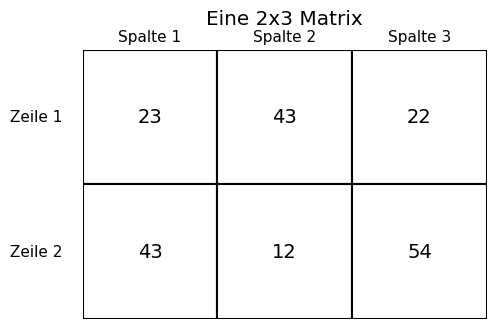

In [ ]:
#@title Bild der Beispiel-Matrix { display-mode: "form" }
def draw_matrix(ax, matrix, title="Matrix", row_labels=None, col_labels=None,
                highlight_rows=None, highlight_cols=None, highlight_cells=None):
    '''Zeichnet eine Matrix als einfaches Raster.'''
    matrix = np.array(matrix)
    highlight_rows = set(highlight_rows or [])
    highlight_cols = set(highlight_cols or [])
    highlight_cells = set(highlight_cells or [])

    n_rows, n_cols = matrix.shape
    ax.set_xlim(0, n_cols)
    ax.set_ylim(0, n_rows)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.axis("off")

    for r in range(n_rows):
        for c in range(n_cols):
            facecolor = "white"
            if r in highlight_rows:
                facecolor = "#fff2a8"
            if c in highlight_cols:
                facecolor = "#d8f3dc"
            if (r, c) in highlight_cells:
                facecolor = "#ffd6a5"

            rect = Rectangle((c, r), 1, 1, facecolor=facecolor, edgecolor="black", linewidth=1.5)
            ax.add_patch(rect)
            ax.text(c + 0.5, r + 0.5, str(matrix[r, c]), ha="center", va="center", fontsize=14)

    if row_labels is not None:
        for r, label in enumerate(row_labels):
            ax.text(-0.15, r + 0.5, label, ha="right", va="center", fontsize=11)

    if col_labels is not None:
        for c, label in enumerate(col_labels):
            ax.text(c + 0.5, -0.15, label, ha="center", va="top", fontsize=11)

    ax.set_title(title, pad=18)


fig, ax = plt.subplots(figsize=(6, 3.5))
draw_matrix(
    ax,
    example_matrix,
    title="Eine 2x3 Matrix",
    row_labels=["Zeile 1", "Zeile 2"],
    col_labels=["Spalte 1", "Spalte 2", "Spalte 3"],
)
plt.show()

## 4. Matrizenmultiplikation: nicht einfach Stelle mal Stelle

Viele denken zuerst:

> Links oben mal links oben, rechts oben mal rechts oben, und so weiter.

Das ist aber **nicht** die Matrizenmultiplikation.

Bei der Matrizenmultiplikation gilt:

> **Eine Zeile der ersten Matrix trifft eine Spalte der zweiten Matrix.**

Das Ergebnis kommt dann in die passende Zelle der neuen Matrix.


In [ ]:
#@title Matrix A und B anzeigen { display-mode: "form" }
A = np.array([
    [1, 2],
    [3, 4],
])

B = np.array([
    [5, 6],
    [7, 8],
])

print("Matrix A")
display(pd.DataFrame(A, index=["Zeile 1", "Zeile 2"], columns=["Spalte 1", "Spalte 2"]))

print("Matrix B")
display(pd.DataFrame(B, index=["Zeile 1", "Zeile 2"], columns=["Spalte 1", "Spalte 2"]))

Matrix A


,Spalte 1,Spalte 2
Zeile 1,1,2
Zeile 2,3,4


Matrix B


,Spalte 1,Spalte 2
Zeile 1,5,6
Zeile 2,7,8


## 5. Die Regel: Zeile mal Spalte

Wir berechnen zuerst die Zelle **oben links** im Ergebnis.

Dafür nehmen wir:

- die **erste Zeile** aus Matrix A: `1, 2`
- die **erste Spalte** aus Matrix B: `5, 7`

Dann rechnen wir:

$1 \cdot 5 + 2 \cdot 7 = 5 + 14 = 19$

Die **19** kommt im Ergebnis oben links hin.


In [ ]:
#@title Regel der Berechnung in der Matrix anzeigen { display-mode: "form" }
def explain_matrix_cell(A, B, row_index, col_index):
    '''Zeigt die Rechnung für eine einzelne Zelle von A @ B.'''
    A = np.array(A)
    B = np.array(B)
    row = A[row_index, :]
    column = B[:, col_index]
    products = row * column
    result = int(products.sum()) if float(products.sum()).is_integer() else products.sum()

    parts = [f"{row[i]} x {column[i]}" for i in range(len(row))]
    product_parts = [str(products[i]) for i in range(len(products))]
    calculation = " + ".join(parts)
    product_sum = " + ".join(product_parts)

    step_df = pd.DataFrame({
        "Zahl aus Zeile von A": row,
        "Zahl aus Spalte von B": column,
        "Produkt": products,
    })

    display(step_df)
    print(f"Rechnung: {calculation} = {product_sum} = {result}")
    return result

result_00 = explain_matrix_cell(A, B, row_index=0, col_index=0)

,Zahl aus Zeile von A,Zahl aus Spalte von B,Produkt
0,1,5,5
1,2,7,14


Rechnung: 1 x 5 + 2 x 7 = 5 + 14 = 19


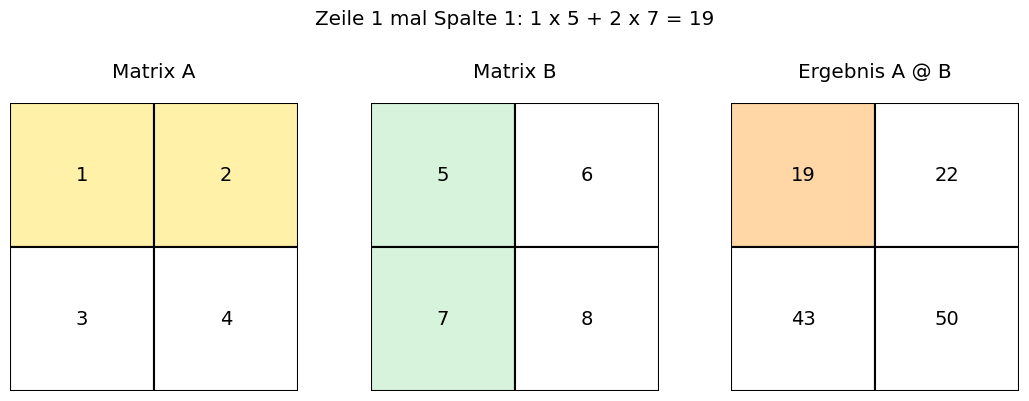

In [ ]:
#@title Diagramm für die Berechnungsregel { display-mode: "form" }
def plot_matrix_multiplication_step(A, B, row_index=0, col_index=0):
    '''Zeigt die Zeile, die Spalte und die Ergebniszelle.'''
    A = np.array(A)
    B = np.array(B)
    C = A @ B

    fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
    draw_matrix(axes[0], A, title="Matrix A", highlight_rows=[row_index])
    draw_matrix(axes[1], B, title="Matrix B", highlight_cols=[col_index])
    draw_matrix(axes[2], C, title="Ergebnis A @ B", highlight_cells=[(row_index, col_index)])

    row = A[row_index, :]
    column = B[:, col_index]
    products = row * column
    text = " + ".join([f"{row[i]} x {column[i]}" for i in range(len(row))])
    fig.suptitle(f"Zeile {row_index + 1} mal Spalte {col_index + 1}: {text} = {products.sum()}", y=1.05)
    plt.tight_layout()
    plt.show()

plot_matrix_multiplication_step(A, B, row_index=0, col_index=0)

## 6. Das ganze Ergebnis

Für eine 2x2 Matrix müssen wir vier Zellen berechnen.

| Zelle im Ergebnis | Rechnung | Ergebnis |
|---|---:|---:|
| oben links | 1 x 5 + 2 x 7 | 19 |
| oben rechts | 1 x 6 + 2 x 8 | 22 |
| unten links | 3 x 5 + 4 x 7 | 43 |
| unten rechts | 3 x 6 + 4 x 8 | 50 |

Mit `numpy` geht das sehr kurz.

> In Python bedeutet `@`: **Matrizenmultiplikation**.


In [ ]:
#@title Ergebnis-Matrix "C" anzeigen { display-mode: "form" }
C = A @ B

print("A @ B ergibt:")
display(pd.DataFrame(C, index=["Zeile 1", "Zeile 2"], columns=["Spalte 1", "Spalte 2"]))

assert np.array_equal(C, np.array([[19, 22], [43, 50]]))
print("Test bestanden: Das Ergebnis stimmt.")

A @ B ergibt:


,Spalte 1,Spalte 2
Zeile 1,19,22
Zeile 2,43,50


Test bestanden: Das Ergebnis stimmt.


## 7. Achtung: `*` ist nicht dasselbe wie `@`

In Python gibt es einen wichtigen Unterschied:

- `A * B` multipliziert Zahlen an gleicher Stelle.
- `A @ B` macht echte Matrizenmultiplikation: **Zeile mal Spalte**.

Beides kann nützlich sein. Für neuronale Netze brauchen wir hier `@`.


In [ ]:
#@title Unterschied zwischen A * B und A @ B zeigen { display-mode: "form" }
elementwise_product = A * B
matrix_product = A @ B

print("A * B: Stelle mal Stelle")
display(pd.DataFrame(elementwise_product, index=["Zeile 1", "Zeile 2"], columns=["Spalte 1", "Spalte 2"]))

print("A @ B: Zeile mal Spalte")
display(pd.DataFrame(matrix_product, index=["Zeile 1", "Zeile 2"], columns=["Spalte 1", "Spalte 2"]))

A * B: Stelle mal Stelle


,Spalte 1,Spalte 2
Zeile 1,5,12
Zeile 2,21,32


A @ B: Zeile mal Spalte


,Spalte 1,Spalte 2
Zeile 1,19,22
Zeile 2,43,50


## 8. Wann darf man Matrizen multiplizieren?

Die Regel ist kurz:

> Die Anzahl **Spalten** der ersten Matrix muss zur Anzahl **Zeilen** der zweiten Matrix passen.

Beispiel:

- Eine **2x3 Matrix** darf man mit einer **3x1 Matrix** multiplizieren.
- Das Ergebnis ist dann eine **2x1 Matrix**.

Man kann sich das so merken:\
$\underbrace{2 \times \mathbf{3}}{\text{erste Matrix}} \cdot \underbrace{\mathbf{3} \times 1}{\text{zweite Matrix}} = \underbrace{2 \times 1}_{\text{Ergebnis}}$

Die **inneren Zahlen** müssen übereinstimmen: $2 \times \mathbf{3} \cdot \mathbf{3} \times 1$\
Die beiden inneren Zahlen sind hier beide **3**. Darum ist die Multiplikation erlaubt.

Die **äusseren Zahlen** geben die Grösse der neuen Matrix an: $\mathbf{2} \times 3 \cdot 3 \times \mathbf{1} \Rightarrow \mathbf{2} \times \mathbf{1}$

Warum?

Jede Zeile der ersten Matrix hat 3 Zahlen.  
Jede Spalte der zweiten Matrix hat auch 3 Zahlen.  
Darum kann man die Zahlen paarweise multiplizieren und addieren.


In [ ]:
#@title Tabelle: Welche Matrizen darf man multiplizieren { display-mode: "form" }
def can_multiply(shape_left, shape_right):
    return shape_left[1] == shape_right[0]

shape_examples = [
    ((2, 2), (2, 2)),
    ((2, 3), (3, 1)),
    ((2, 3), (2, 1)),
    ((4, 5), (5, 2)),
]

rows = []
for left_shape, right_shape in shape_examples:
    possible = can_multiply(left_shape, right_shape)
    if possible:
        result_shape = (left_shape[0], right_shape[1])
        result_text = f"{result_shape[0]}x{result_shape[1]}"
    else:
        result_text = "geht nicht"

    rows.append({
        "erste Matrix": f"{left_shape[0]}x{left_shape[1]}",
        "zweite Matrix": f"{right_shape[0]}x{right_shape[1]}",
        "passt?": "ja" if possible else "nein",
        "Form des Ergebnisses": result_text,
    })

shape_df = pd.DataFrame(rows)
display(shape_df)

,erste Matrix,zweite Matrix,passt?,Form des Ergebnisses
0,2x2,2x2,ja,2x2
1,2x3,3x1,ja,2x1
2,2x3,2x1,nein,geht nicht
3,4x5,5x2,ja,4x2


## 9. Verbindung zu neuronalen Netzen

Jetzt kommt der wichtige Teil.

In Colab 05 hatten wir ein kleines Netz mit:

- **2 Eingängen**
- **2 Ausgabeneuronen**

Jedes Ausgabeneuron bekommt beide Eingaben.

Die Einzelrechnungen waren:

$\text{Neuron 1}: 1.0 \cdot 0.9 + 0.5 \cdot 0.3 = 1.05$

$\text{Neuron 2}: 1.0 \cdot 0.2 + 0.5 \cdot 0.8 = 0.60$

Mit Matrizen schreiben wir das kurz so:

$X = W \cdot I$

In Python schreiben wir:

```python
X = W @ I
```

Dabei gilt:

- `I` ist die Eingabematrix.
- `W` ist die Gewichtsmatrix.
- `X` sind die Summen vor der Aktivierungsfunktion.


In [ ]:
#@title Matrizenrechnung im neuronalen Netz anzeigen { display-mode: "form" }
I = np.array([
    [1.0],
    [0.5],
])

W = np.array([
    [0.9, 0.3],
    [0.2, 0.8],
])

input_df = pd.DataFrame(I, index=["Input 1", "Input 2"], columns=["Signal"])
weight_df = pd.DataFrame(W, index=["Neuron 1", "Neuron 2"], columns=["Input 1", "Input 2"])

print("Eingabematrix I")
display(input_df.style.format("{:.2f}"))

print("Gewichtsmatrix W")
display(weight_df.style.format("{:.2f}"))

print(f"Form von W: {W.shape[0]}x{W.shape[1]}")
print(f"Form von I: {I.shape[0]}x{I.shape[1]}")

Eingabematrix I


,Signal
Input 1,1.00
Input 2,0.50


Gewichtsmatrix W


,Input 1,Input 2
Neuron 1,0.90,0.30
Neuron 2,0.20,0.80


Form von W: 2x2
Form von I: 2x1


## 10. Das Netz mit einer einzigen Matrixrechnung

Jetzt rechnet `numpy` beide Neuronen auf einmal aus.

$X = W \cdot I$

Das bedeutet:

- Zeile 1 von `W` rechnet Neuron 1.
- Zeile 2 von `W` rechnet Neuron 2.
- Die Spalte `I` enthält die Eingaben.


In [ ]:
#@title Matrizenrechnung im neuronalen Netz einsetzen { display-mode: "form" }
X = W @ I

x_df = pd.DataFrame(X, index=["Neuron 1", "Neuron 2"], columns=["Summe X"])

display(x_df.style.format("{:.2f}"))

print(f"Neuron 1: {W[0, 0]:.1f} x {I[0, 0]:.1f} + {W[0, 1]:.1f} x {I[1, 0]:.1f} = {X[0, 0]:.2f}")
print(f"Neuron 2: {W[1, 0]:.1f} x {I[0, 0]:.1f} + {W[1, 1]:.1f} x {I[1, 0]:.1f} = {X[1, 0]:.2f}")

assert np.allclose(X, np.array([[1.05], [0.60]]))
print("Test bestanden: Die Matrixrechnung passt zu Colab 05.")

,Summe X
Neuron 1,1.05
Neuron 2,0.60


Neuron 1: 0.9 x 1.0 + 0.3 x 0.5 = 1.05
Neuron 2: 0.2 x 1.0 + 0.8 x 0.5 = 0.60
Test bestanden: Die Matrixrechnung passt zu Colab 05.


## 11. Bild des kleinen Netzes

Die Gewichtsmatrix `W` merkt sich alle Verbindungen.

Wichtig:

> Eine Zeile von `W` gehört zu einem Ausgabeneuron.

- Zeile 1 von `W`: Gewichte für Neuron 1
- Zeile 2 von `W`: Gewichte für Neuron 2


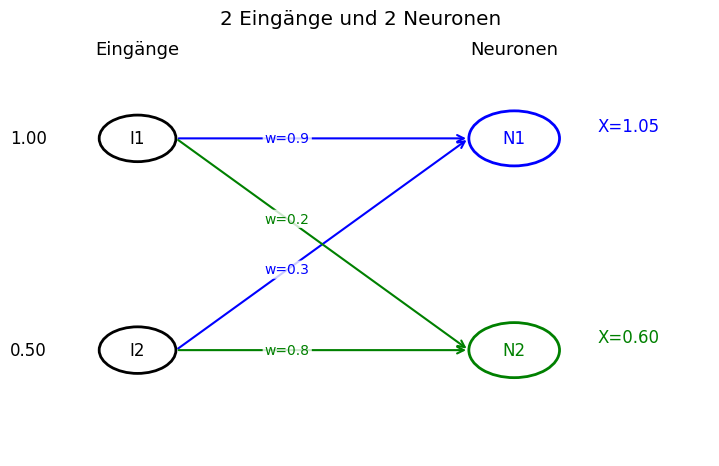

In [ ]:
#@title Bild des neuronalen Beispiel-Netzes { display-mode: "form" }
def plot_small_network(input_matrix, weight_matrix, sums=None, outputs=None,
                       title="Kleines Netz", show_weights=True, neuron_colors=None):
    input_values = input_matrix.flatten()
    n_inputs = len(input_values)
    n_outputs = weight_matrix.shape[0]

    # Standardfarben für die Zielneuronen
    if neuron_colors is None:
        default_colors = ["blue", "green", "orange", "red", "purple", "brown"]
        neuron_colors = [default_colors[j % len(default_colors)] for j in range(n_outputs)]

    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    input_y = np.linspace(0.75, 0.25, n_inputs)
    output_y = np.linspace(0.75, 0.25, n_outputs)
    x_left = 0.18
    x_right = 0.72

    ax.text(x_left, 0.95, "Eingänge", ha="center", fontsize=13)
    ax.text(x_right, 0.95, "Neuronen", ha="center", fontsize=13)

    # Eingänge zeichnen
    for i, y in enumerate(input_y):
        circle = Circle((x_left, y), 0.055, fill=False, linewidth=2, edgecolor="black")
        ax.add_patch(circle)
        ax.text(x_left, y, f"I{i + 1}", ha="center", va="center")
        ax.text(x_left - 0.13, y, f"{input_values[i]:.2f}", ha="right", va="center")

    # Ausgabeneuronen zeichnen
    for j, y in enumerate(output_y):
        color = neuron_colors[j]

        circle = Circle((x_right, y), 0.065, fill=False, linewidth=2, edgecolor=color)
        ax.add_patch(circle)
        ax.text(x_right, y, f"N{j + 1}", ha="center", va="center", color=color)

        if sums is not None:
            ax.text(x_right + 0.12, y + 0.03, f"X={sums[j, 0]:.2f}",
                    ha="left", va="center", color=color)

        if outputs is not None:
            ax.text(x_right + 0.12, y - 0.04, f"O={outputs[j, 0]:.2f}",
                    ha="left", va="center", color=color)

    # Verbindungen und Gewichte zeichnen
    for j, y_out in enumerate(output_y):
        color = neuron_colors[j]

        for i, y_in in enumerate(input_y):
            ax.annotate(
                "",
                xy=(x_right - 0.065, y_out),
                xytext=(x_left + 0.055, y_in),
                arrowprops=dict(arrowstyle="->", linewidth=1.5, color=color),
            )

            if show_weights:
                # Beschriftung etwas näher beim Eingang
                start_x = x_left + 0.055
                end_x = x_right - 0.065
                label_t = 0.38
                label_x = start_x + label_t * (end_x - start_x)
                label_y = y_in + label_t * (y_out - y_in)

                ax.text(
                    label_x,
                    label_y,
                    f"w={weight_matrix[j, i]:.1f}",
                    ha="center",
                    va="center",
                    fontsize=10,
                    color=color,
                    bbox=dict(
                        boxstyle="round,pad=0.15",
                        facecolor="white",
                        edgecolor="none",
                        alpha=0.8
                    )
                )

    ax.set_title(title)
    plt.show()

plot_small_network(I, W, sums=X, title="2 Eingänge und 2 Neuronen")

## 12. Die Sigmoidfunktion auf alle Werte anwenden

In Colab 05 haben wir nach der Summe noch eine Aktivierungsfunktion genutzt.

Hier machen wir dasselbe.

Die Matrixrechnung liefert:

$X = W \cdot I$

Danach kommt:

$O = \text{sigmoid}(X)$

Das heisst:

> Die Sigmoidfunktion wird auf jede Zahl in `X` angewendet.


,Neuron,Summe X,Ausgabe O = sigmoid(X)
0,Neuron 1,1.05,0.741
1,Neuron 2,0.60,0.646


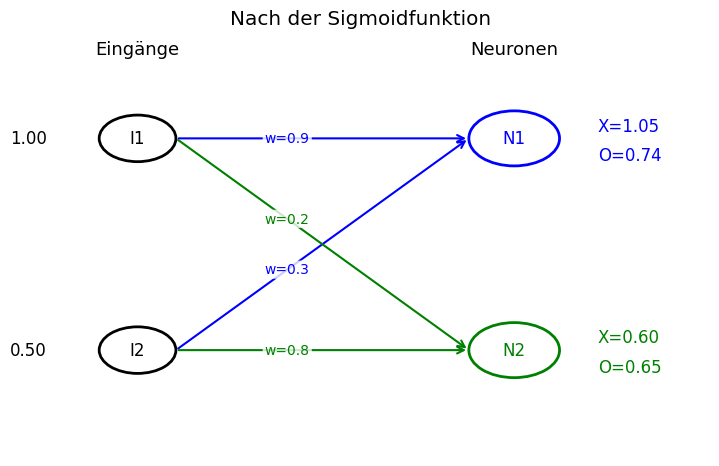

In [ ]:
#@title Diagramm: Nach der Sigmoidfunktion { display-mode: "form" }
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

O = sigmoid(X)

activation_df = pd.DataFrame({
    "Neuron": ["Neuron 1", "Neuron 2"],
    "Summe X": X.flatten(),
    "Ausgabe O = sigmoid(X)": O.flatten(),
})

display(activation_df.style.format({
    "Summe X": "{:.2f}",
    "Ausgabe O = sigmoid(X)": "{:.3f}",
}))

plot_small_network(I, W, sums=X, outputs=O, title="Nach der Sigmoidfunktion")

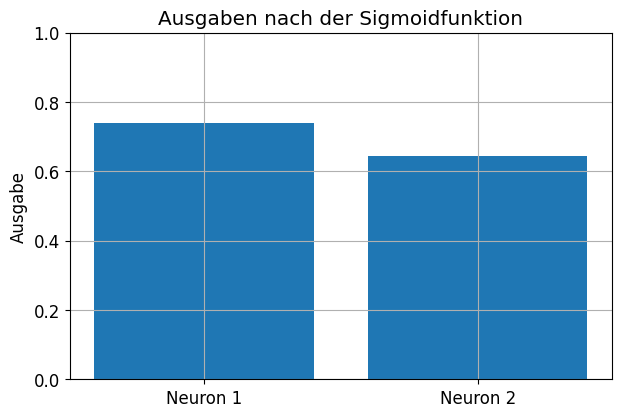

In [ ]:
#@title Diagramm: Ausgaben nach der Sigmoidfunktion { display-mode: "form" }
fig, ax = plt.subplots(figsize=(7, 4.5))
labels = activation_df["Neuron"].values
positions = np.arange(len(labels))

ax.bar(positions, activation_df["Ausgabe O = sigmoid(X)"].values)
ax.set_xticks(positions)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_ylabel("Ausgabe")
ax.set_title("Ausgaben nach der Sigmoidfunktion")
plt.show()

## 13. Warum ist das nützlich?

Stell dir ein Netz mit vielen Neuronen vor.

Ohne Matrizen müssten wir sehr viele Einzelrechnungen aufschreiben:

- jede Eingabe mal ein Gewicht
- alles addieren
- das für jedes Neuron wiederholen

Mit Matrizen schreiben wir nur:

$X = W \cdot I$

Oder in Python:

```python
X = W @ I
```

Der Computer macht dann die ganze Fleissarbeit.


## 14. Ein etwas grösseres Beispiel: 3 Eingänge und 3 Neuronen

Jetzt sehen wir den Vorteil noch klarer.

Wir nehmen:

- 3 Eingänge
- 3 Neuronen

Jedes Neuron bekommt alle 3 Eingänge.

Darum hat die Gewichtsmatrix `W3` die Form **3x3**.

Die Eingabematrix `I3` hat die Form **3x1**.

Das Ergebnis `X3` hat die Form **3x1**.


In [ ]:
#@title Beispiel mit 3 Eingängen und 3 Neuronen { display-mode: "form" }
I3 = np.array([
    [0.9],
    [0.1],
    [0.8],
])

W3 = np.array([
    [0.9, 0.3, 0.4],
    [0.2, 0.8, 0.2],
    [0.1, 0.5, 0.9],
])

X3 = W3 @ I3
O3 = sigmoid(X3)

print(f"Form von W3: {W3.shape[0]}x{W3.shape[1]}")
print(f"Form von I3: {I3.shape[0]}x{I3.shape[1]}")
print(f"Form von X3: {X3.shape[0]}x{X3.shape[1]}")

print("Eingaben I3")
display(pd.DataFrame(I3, index=["Input 1", "Input 2", "Input 3"], columns=["Signal"]).style.format("{:.2f}"))

print("Gewichte W3")
display(pd.DataFrame(
    W3,
    index=["Neuron 1", "Neuron 2", "Neuron 3"],
    columns=["Input 1", "Input 2", "Input 3"],
).style.format("{:.2f}"))

print("Ergebnis")
display(pd.DataFrame({
    "Neuron": ["Neuron 1", "Neuron 2", "Neuron 3"],
    "Summe X3": X3.flatten(),
    "Ausgabe O3": O3.flatten(),
}).style.format({"Summe X3": "{:.3f}", "Ausgabe O3": "{:.3f}"}))

Form von W3: 3x3
Form von I3: 3x1
Form von X3: 3x1
Eingaben I3


,Signal
Input 1,0.90
Input 2,0.10
Input 3,0.80


Gewichte W3


,Input 1,Input 2,Input 3
Neuron 1,0.90,0.30,0.40
Neuron 2,0.20,0.80,0.20
Neuron 3,0.10,0.50,0.90


Ergebnis


,Neuron,Summe X3,Ausgabe O3
0,Neuron 1,1.160,0.761
1,Neuron 2,0.420,0.603
2,Neuron 3,0.860,0.703


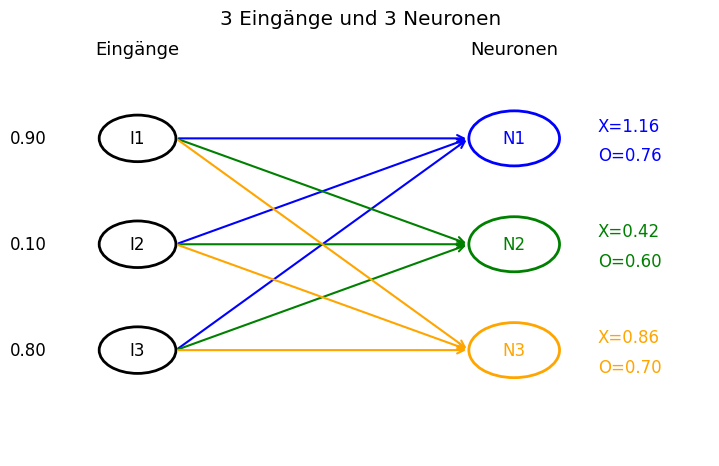

In [ ]:
#@title Diagramm: 3 Eingänge und 3 Neuronen { display-mode: "form" }
plot_small_network(I3, W3, sums=X3, outputs=O3, title="3 Eingänge und 3 Neuronen", show_weights=False)

## 15. Spielwiese

Jetzt kannst du selbst experimentieren.

Ändere die Zahlen in `play_I` und `play_W`.

Achte auf die Formen:

- `play_W` ist hier **2x3**.
- `play_I` ist hier **3x1**.
- Das Ergebnis ist dann **2x1**.

Das passt, weil die innere Zahl gleich ist:

$2x\mathbf{3} \cdot \mathbf{3}x1$


In [ ]:
play_I = np.array([
    [1.0], # Hier Input 1 ändern
    [0.5], # Hier Input 2 ändern
    [0.2], # Hier Input 3 ändern
])

play_W = np.array([
    [0.9, 0.3, 0.1], # Hier Gewichte Neuron 1 ändern
    [0.2, 0.8, 0.4], # Hier Gewichte Neuron 2 ändern (Für ein neues Neuron eine Gewichte-Zeile hinzufügen!)
])

,Neuron,Summe X,Ausgabe O
0,Neuron 1,1.070,0.745
1,Neuron 2,0.680,0.664


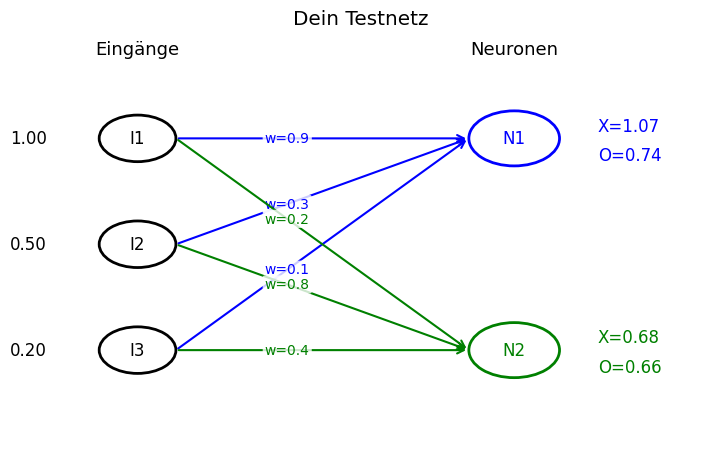

In [ ]:
#@title Experiment starten starten { display-mode: "form" }
if play_W.shape[1] != play_I.shape[0]:
    raise ValueError("Die Formen passen nicht: Spalten von play_W müssen zu Zeilen von play_I passen.")

play_X = play_W @ play_I
play_O = sigmoid(play_X)

play_result_df = pd.DataFrame({
    "Neuron": [f"Neuron {i + 1}" for i in range(play_W.shape[0])],
    "Summe X": play_X.flatten(),
    "Ausgabe O": play_O.flatten(),
})

display(play_result_df.style.format({"Summe X": "{:.3f}", "Ausgabe O": "{:.3f}"}))
plot_small_network(play_I, play_W, sums=play_X, outputs=play_O, title="Dein Testnetz")

## 16. Mini-Aufgaben

1. Ändere in der Spielwiese einen Eingang. Was passiert mit den Ausgaben?
2. Ändere ein Gewicht. Welches Neuron verändert sich stärker?
3. Erkläre den Unterschied zwischen `A * B` und `A @ B` mit eigenen Worten.
4. Prüfe die Formen: Darf man eine 2x4 Matrix mit einer 4x1 Matrix multiplizieren?
5. Baue in der Spielwiese ein Netz mit **3 Neuronen** und **3 Eingängen**.

Tipp für Aufgabe 5:

- `play_W` braucht dann 3 Zeilen und 3 Spalten.
- `play_I` braucht 3 Zeilen und 1 Spalte.


## 17. Merksätze

- Eine Matrix ist eine **Tabelle mit Zahlen**.
- Die Form einer Matrix ist **Zeilen x Spalten**.
- Matrizenmultiplikation bedeutet: **Zeile mal Spalte**.
- In Python bedeutet `@`: **Matrizenmultiplikation**.
- In Python bedeutet `*`: **Stelle mal Stelle**.
- Für neuronale Netze ist besonders wichtig:

$X = W \cdot I$

- `W` enthält die Gewichte.
- `I` enthält die Eingaben.
- `X` enthält die Summen vor der Aktivierungsfunktion.
- Danach kann man schreiben:

$O = \text{sigmoid}(X)$

> Kurz gesagt: Matrizen helfen uns, viele kleine Rechnungen kurz und übersichtlich aufzuschreiben.


Copyright 2026 [Markus Ineichen](mailto:markus.ineichen1@sluz.ch)

Code licence: [MIT License](https://mit-license.org/)

Text license: [Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International](https://creativecommons.org/licenses/by-nc-sa/4.0/)
